# Lab Assignment 1: Data Cleaning & Preprocessing (AI in Healthcare)

**Course:** B.Tech Specialization Elective (4th Year, Sem VII)  
**Course Code:** CSET343 - AI in Healthcare  
**Assignment:** Lab Assignment 1 - Data Cleaning, Missing Value Imputation, Outlier Handling, and Feature Scaling on Heart Failure Clinical Records


In [2]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein humne required libraries import kiye aur Heart Failure
# dataset ko online URL se load karke DataFrame mein store kiya.
# Step 1: Pandas, NumPy, Matplotlib aur Seaborn libraries import ki.
# Step 2: GitHub se CSV dataset read kiya 'df' variable mein.
# Step 3: Dataset ka initial shape print karke confirmation check kiya.
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/dimikara/Survival-Prediction-of-Patients-with-Heart-Failure/master/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset downloaded successfully!")
print("Shape:", df.shape)

Dataset downloaded successfully!
Shape: (299, 13)


In [3]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein dataset ke pehle 5 rows (records) display kiye gaye hain.
# Step 1: df.head() function use karke top 5 patient rows print kiye taaki
#         columns aur values ka format samajh aa sake.
# ====================================================================
print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [4]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein dataset ke basic dimensions, column types aur missing values check kiye.
# Step 1: Total rows aur columns ka count inspect kiya.
# Step 2: Sabhi columns ka data type (integer/float) verify kiya.
# Step 3: Har feature mein kitne missing values (nulls) hain, wo count kiya.
# ====================================================================
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


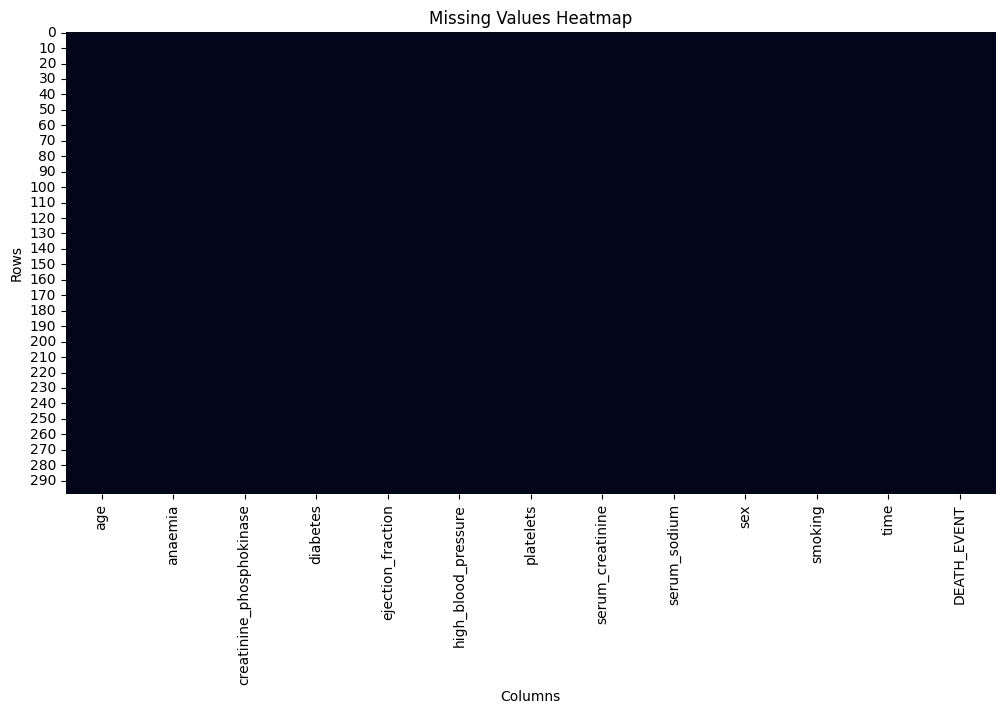

In [5]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein missing data ko visual format mein dekhne ke liye heatmap banaya.
# Step 1: Matplotlib figure initialize kiya 12x6 dimensions ke saath.
# Step 2: Seaborn ka heatmap use karke df.isnull() ko plot kiya.
# Step 3: Heatmap se confirm hua ki raw data mein missing values hain ya nahi.
# ====================================================================
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [6]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein data cleaning experimentation ke liye intentional missing values inject kiye.
# Step 1: Original df ki safe copy banayi 'df_exp'.
# Step 2: 'age', 'serum_creatinine', aur 'ejection_fraction' ke selected rows mein np.nan daala.
# Step 3: Missing count print karke verify kiya ki null values create ho gaye.
# ====================================================================
# Create a copy for experimentation
df_exp = df.copy()

# Create some missing values
df_exp.loc[1, "age"] = np.nan
df_exp.loc[5, "serum_creatinine"] = np.nan
df_exp.loc[10, "ejection_fraction"] = np.nan

# Check missing values
print(df_exp.isnull().sum())

age                         1
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           1
high_blood_pressure         0
platelets                   0
serum_creatinine            1
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [7]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein missing numerical values ko Median Imputation se fill kiya gaya hai.
# Step 1: 'age' column ke missing values ko median age se fill kiya.
# Step 2: 'serum_creatinine' aur 'ejection_fraction' ke nulls ko unke median se fill kiya.
# Step 3: Phir se null count check kiya verify karne ke liye ki zero missing values bache.
# ====================================================================
# Fill missing numerical values with median

df_exp["age"] = df_exp["age"].fillna(df_exp["age"].median())
df_exp["serum_creatinine"] = df_exp["serum_creatinine"].fillna(
    df_exp["serum_creatinine"].median()
)
df_exp["ejection_fraction"] = df_exp["ejection_fraction"].fillna(
    df_exp["ejection_fraction"].median()
)

# Check missing values after imputation
print(df_exp.isnull().sum())


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [8]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Interquartile Range (IQR) method use karke extreme outliers ko remove kiya gaya.
# Step 1: Numerical columns identify kiye.
# Step 2: Har feature ka Q1 (25th percentile) aur Q3 (75th percentile) nikal kar IQR calculate kiya.
# Step 3: Lower limit (Q1 - 1.5*IQR) aur upper limit (Q3 + 1.5*IQR) define ki.
# Step 4: Jo rows limits ke bahar the unhe drop kiya aur rows count compare kiya.
# ====================================================================
# Remove outliers using IQR method

numerical_columns = df_exp.select_dtypes(include=np.number).columns

df_clean = df_exp.copy()

for col in numerical_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_limit) &
        (df_clean[col] <= upper_limit)
    ]

print("Original rows:", len(df_exp))
print("Rows after removing outliers:", len(df_clean))

Original rows: 299
Rows after removing outliers: 224


In [9]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein clinical inconsistency test karne ke liye deliberate invalid negative age daali.
# Step 1: Cleaned data ki copy banayi inconsistency auditing ke liye.
# Step 2: Index 0 par patient ki age -10 kardi (jo clinically impossible hai).
# Step 3: Negative ages filter karke print kiya invalid records identify karne ke liye.
# ====================================================================
# Create a copy for inconsistency checking
df_clean = df_clean.copy()

# Create an invalid age for experimentation
df_clean.loc[0, "age"] = -10

print("Invalid ages:")
print(df_clean[df_clean["age"] < 0])

Invalid ages:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0 -10.0        0                       582         0               20.0   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1   265000.0               1.9           130    1   

   smoking  time  DEATH_EVENT  
0        0     4            1  


In [10]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein inconsistent negative ages ko rectify kiya gaya.
# Step 1: Jitne bhi negative age values the unhe pehle np.nan mein convert kiya.
# Step 2: Phir un NaN values ko median age se impute kiya.
# Step 3: Verify kiya ki ab koi negative ya missing age nahi bachi.
# ====================================================================
# Replace invalid negative ages with NaN
df_clean.loc[df_clean["age"] < 0, "age"] = np.nan

# Fill the resulting missing age with the median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

print("Negative ages remaining:", (df_clean["age"] < 0).sum())
print("Missing ages remaining:", df_clean["age"].isnull().sum())

Negative ages remaining: 0
Missing ages remaining: 0


In [12]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein continuous 'age' ko clinical 'age_group' categories mein convert kiya (Feature Engineering).
# Step 1: pd.cut() use karke age ranges define kiye: '<40', '40-60', aur '>60'.
# Step 2: Naya categorical feature 'age_group' create kiya.
# Step 3: Top 10 rows print karke check kiya ki grouping sahi se apply hui.
# ====================================================================
# Create age_group feature

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

print(df_clean[["age", "age_group"]].head(10))

     age age_group
0   60.0       >60
2   65.0       >60
3   50.0     40-60
5   90.0       >60
6   75.0       >60
8   65.0       >60
11  62.0       >60
12  45.0     40-60
13  50.0     40-60
14  49.0     40-60


In [13]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein domain-specific Cardiac Risk Score create aur normalize kiya gaya.
# Step 1: Ejection fraction aur serum creatinine ko multiply karke raw risk score banaya.
# Step 2: Min-Max formula use karke risk score ko 0 se 1 ke scale par normalize kiya.
# Step 3: Engineered risk score ke sample values display kiye.
# ====================================================================
df_clean["risk_score_raw"] = (
    df_clean["ejection_fraction"] *
    df_clean["serum_creatinine"]
)
df_clean["risk_score"] = (
    (df_clean["risk_score_raw"] - df_clean["risk_score_raw"].min()) /
    (df_clean["risk_score_raw"].max() - df_clean["risk_score_raw"].min())
)
print(df_clean[[
    "ejection_fraction",
    "serum_creatinine",
    "risk_score"
]].head(10))

    ejection_fraction  serum_creatinine  risk_score
0                20.0               1.9    0.310545
2                20.0               1.3    0.171495
3                20.0               1.9    0.310545
5                40.0               1.1    0.380070
6                15.0               1.2    0.078795
8                65.0               1.5    1.000000
11               25.0               0.9    0.130939
12               30.0               1.1    0.252607
13               38.0               1.1    0.354577
14               30.0               1.0    0.217845


In [14]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein categorical variables ko One-Hot Encoding ke through binary numeric columns banaya.
# Step 1: 'sex' aur 'smoking' columns ko string type mein cast kiya.
# Step 2: pd.get_dummies() use karke binary 0/1 indicators generate kiye.
# Step 3: Encoded dataset ka structure preview kiya.
# ====================================================================
# Convert sex and smoking into categorical data

df_clean["sex"] = df_clean["sex"].astype(str)
df_clean["smoking"] = df_clean["smoking"].astype(str)

# One-hot encode categorical variables

df_clean = pd.get_dummies(
    df_clean,
    columns=["sex", "smoking"],
    prefix=["sex", "smoking"],
    dtype=int
)

print(df_clean.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  60.0        0                       582         0               20.0   
2  65.0        0                       146         0               20.0   
3  50.0        1                       111         0               20.0   
5  90.0        1                        47         0               40.0   
6  75.0        1                       246         0               15.0   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  time  \
0                    1   265000.0               1.9           130     4   
2                    0   162000.0               1.3           129     7   
3                    0   210000.0               1.9           137     7   
5                    1   204000.0               1.1           132     8   
6                    0   127000.0               1.2           137    10   

   DEATH_EVENT age_group  risk_score_raw  risk_score  sex_0  sex_1  smoking_0  \
0            1   

In [16]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein MinMaxScaler use karke continuous numerical features ko [0, 1] range mein scale kiya.
# Step 1: Scikit-learn se MinMaxScaler initialize kiya.
# Step 2: 'age' aur 'platelets' columns par fit_transform() lagaya.
# Step 3: Scaled features ke pehle kuch rows verify karne ke liye print kiye.
# ====================================================================
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_columns = ["age", "platelets"]

df_clean[numerical_columns] = scaler.fit_transform(
    df_clean[numerical_columns]
)

print(df_clean[numerical_columns].head())

        age  platelets
0  0.363636   0.468852
2  0.454545   0.131148
3  0.181818   0.288525
5  0.909091   0.268852
6  0.636364   0.016393


In [17]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein data cleaning se pehle aur baad ke summary statistics compare kiye gaye.
# Step 1: Raw data ka mean, median aur standard deviation calculate kiya.
# Step 2: Cleaned data ke statistics nikal kar cleaning aur scaling ka asar verify kiya.
# ====================================================================
# Summary statistics BEFORE cleaning

print("BEFORE CLEANING")
print(df[["age", "platelets"]].agg(["mean", "median", "std"]))

print("\nAFTER CLEANING")
print(df_clean[["age", "platelets"]].agg(["mean", "median", "std"]))

BEFORE CLEANING
              age      platelets
mean    60.833893  263358.029264
median  60.000000  262000.000000
std     11.894809   97804.236869

AFTER CLEANING
             age  platelets
mean    0.377137   0.438902
median  0.363636   0.460656
std     0.216512   0.220176


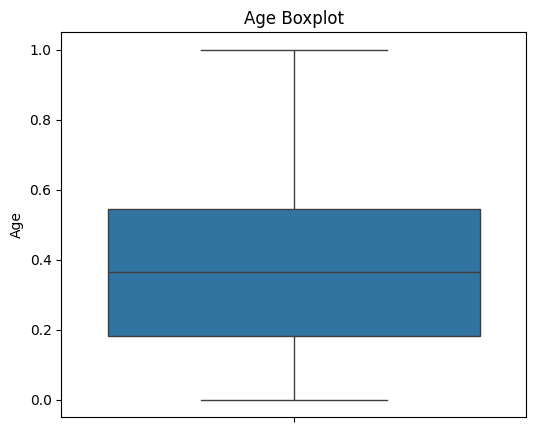

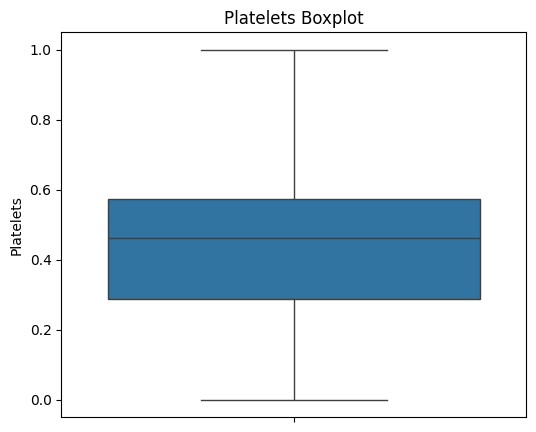

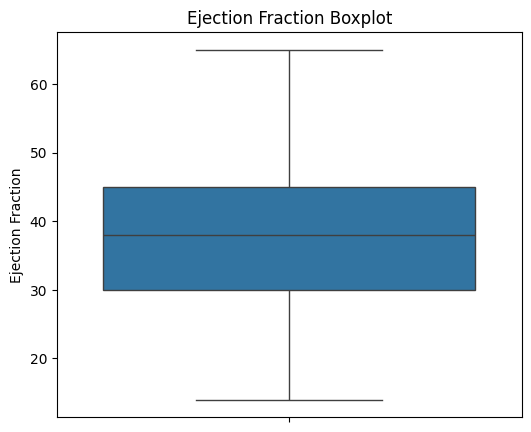

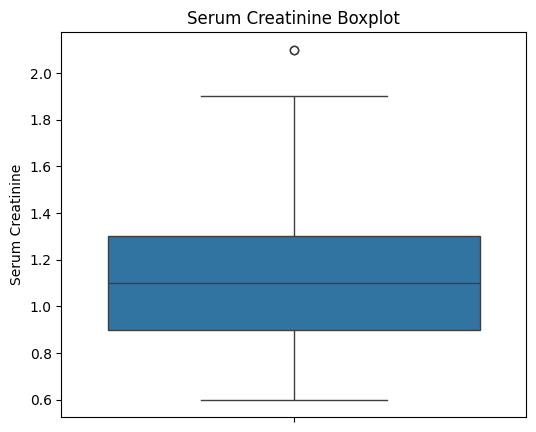

In [19]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein cleaned numerical variables ke boxplots visualize kiye gaye hain.
# Step 1: Age, Platelets, Ejection Fraction, aur Serum Creatinine ke individual boxplots plot kiye.
# Step 2: Boxplots ke distribution se check kiya ki ab koi abnormal extreme outliers nahi hain.
# ====================================================================
# Age
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_clean["age"])
plt.title("Age Boxplot")
plt.ylabel("Age")
plt.show()


# Platelets
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_clean["platelets"])
plt.title("Platelets Boxplot")
plt.ylabel("Platelets")
plt.show()


# Ejection Fraction
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_clean["ejection_fraction"])
plt.title("Ejection Fraction Boxplot")
plt.ylabel("Ejection Fraction")
plt.show()


# Serum Creatinine
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_clean["serum_creatinine"])
plt.title("Serum Creatinine Boxplot")
plt.ylabel("Serum Creatinine")
plt.show()

In [20]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein final validation check lagaya gaya hai ki data modeling ke liye ready hai ya nahi.
# Step 1: Sabhi columns mein missing values ka total sum verify kiya (zero nulls).
# Step 2: Final clean DataFrame ka total row aur column shape print kiya.
# ====================================================================
# Final validation of missing values

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nTotal missing values:")
print(df_clean.isnull().sum().sum())

print("\nFinal dataset shape:")
print(df_clean.shape)

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score_raw              0
risk_score                  0
sex_0                       0
sex_1                       0
smoking_0                   0
smoking_1                   0
dtype: int64

Total missing values:
0

Final dataset shape:
(224, 18)
